In [1]:
import sys
sys.path.insert(0, '../')
import data_generation.SimulatorWaveEquation as simu
import numpy as np
from data_generation import DataPlotter as dp
import matplotlib.pyplot as plt

In [17]:
R = 1 # Radius
C = 1 # Wave speed
Lmax = 30 # Maximum degree of spherical harmonics
tmax = 5 # Maximum time  

omega_max = (C/R) * np.sqrt(Lmax*(Lmax+1))
T_min = 2*np.pi / omega_max
dt = T_min / 20
print(dt)
generations = 5 # level of refinement for the grid
center = np.array([0, -R, R])
center = R * center / np.linalg.norm(center)
x0, y0, z0 = center  # Initial position of the gaussian pulse
sigma_deg = 15 # Standard deviation of the Gaussian pulse in degrees
sigma = sigma_deg*np.pi/180 # Standard deviation of the Gaussian pulse in radians   
A = 1 # Amplitude of the Gaussian pulse

# Initial condition: Gaussian pulse centered at (x0, y0, z0)
def f_handle(x, y, z):
    # dot product with center
    dot = x*x0 + y*y0 + z*z0
    
    cos_alpha = np.clip(dot / R**2, -1.0, 1.0)

    alpha = np.arccos(cos_alpha)
     
    return A*np.exp(-(alpha**2) / (2*sigma**2))

# Initital condition: zero initial velocity
g_handle = lambda x, y, z: 0 * x


0.010301688138666264


In [25]:
sim = simu.SimulatorWaveEquation(R=1.0, C=C, Lmax=Lmax, tmax=tmax, f_handle=f_handle, g_handle=g_handle, generations=6, dt = dt)

In [19]:
ds = sim.simulate(savedata=False,savegraph=False)  # (time, N) 

In [26]:
print("clf:",sim.clf_value)
print("dx:",sim.dx)
print("dt:",sim.dt)

clf: 0.5881580466504198
dx: 0.017515169940009713
dt: 0.010301688138666264


In [21]:
def degree_spectrum(ulm):
    Lmax = ulm.shape[0] - 1
    spec = np.zeros(Lmax + 1)
    for ell in range(Lmax + 1):
        # valid m for this ell are -ell..ell, which correspond to columns (Lmax-ell):(Lmax+ell+1)
        col0 = Lmax - ell
        col1 = Lmax + ell+1 
        spec[ell] = np.sum(np.abs(ulm[ell, col0:col1])**2)
    return spec

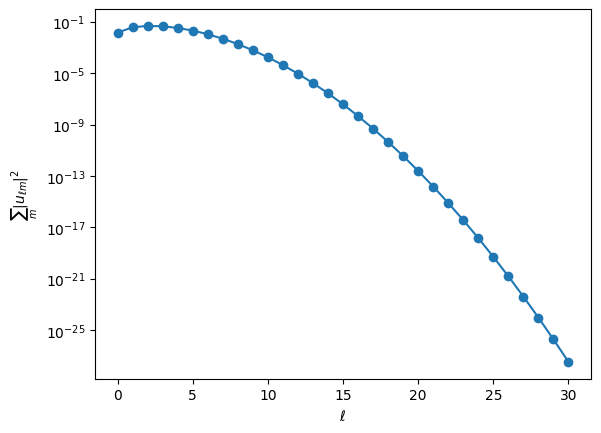

In [22]:
coeffs = sim.get_spectral_coeffs(t=0.0)
ulm = coeffs["ulm"]

E = degree_spectrum(ulm)
import matplotlib.pyplot as plt
plt.semilogy(E,'-o')   # avoid log(0)
plt.xlabel("$\ell$")
plt.ylabel("$\sum_m |u_{\ell m}|^2$")
plt.show()